In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_theme(style='whitegrid')

In [39]:
df = pd.read_csv('../data/archive/steam_games.csv')
print(df.shape)
df.head()

(15000, 43)


,serial_no,game_id,title,release_date,release_year,all_genres,theme,art_style,view_dimension,game_mode,...,cover_image_url,official_website,url_slug,description_clean,popularity_score,engagement_score,decade,is_multi_platform,rating_tier,metacritic_tier
0,1,3498,Grand Theft Auto V,2013-09-17,2013.0,Action,Crime,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/20a/20aa03a1...,http://www.rockstargames.com/V/,grand-theft-auto-v,"Rockstar Games went bigger, since their previo...",96.28,21.75,2010s,1,excellent,universal_acclaim
1,2,3328,The Witcher 3: Wild Hunt,2015-05-18,2015.0,Action|RPG,Fantasy,Realistic,3D,Singleplayer,...,https://media.rawg.io/media/games/618/618c2031...,https://thewitcher.com/en/witcher3,the-witcher-3-wild-hunt,"The third game in a series, it holds nothing b...",95.81,17.19,2010s,1,masterpiece,universal_acclaim
2,3,4200,Portal 2,2011-04-18,2011.0,Shooter|Puzzle,Sci-Fi,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/2ba/2bac0e87...,http://www.thinkwithportals.com/,portal-2,Portal 2 is a first-person puzzle game develop...,91.26,15.24,2010s,1,masterpiece,universal_acclaim
3,4,4291,Counter-Strike: Global Offensive,2012-08-21,2012.0,Shooter,Horror,Realistic,3D,Multiplayer,...,https://media.rawg.io/media/games/736/73619bd3...,http://blog.counter-strike.net/,counter-strike-global-offensive,Counter-Strike is a multiplayer phenomenon in ...,73.56,8.79,2010s,1,good,generally_favorable
4,5,5286,Tomb Raider (2013),2013-03-05,2013.0,Action,Adventure,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/021/021c4e21...,http://www.tombraider.com,tomb-raider,A cinematic revival of the series in its actio...,76.54,13.77,2010s,1,excellent,generally_favorable


In [2]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\Josiah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   serial_no           15000 non-null  int64  
 1   game_id             15000 non-null  int64  
 2   title               15000 non-null  str    
 3   release_date        15000 non-null  str    
 4   release_year        15000 non-null  float64
 5   all_genres          15000 non-null  str    
 6   theme               15000 non-null  str    
 7   art_style           15000 non-null  str    
 8   view_dimension      15000 non-null  str    
 9   game_mode           15000 non-null  str    
 10  is_multiplayer      15000 non-null  int64  
 11  controls            15000 non-null  str    
 12  developers          15000 non-null  str    
 13  publishers          15000 non-null  str    
 14  all_platforms       15000 non-null  str    
 15  platform_count      15000 non-null  float64
 16  esrb_rating    

In [12]:
df.isnull().sum().sort_values(ascending=False).head(10)

metacritic        886
user_rating       387
serial_no           0
release_date        0
release_year        0
all_genres          0
theme               0
art_style           0
view_dimension      0
game_id             0
dtype: int64

In [41]:
# Keep only useful columns — adjust names to match his actual CSV
cols = ['title', 'release_date', 'all_genres', 'all_platforms',
        'user_rating', 'metacritic','avg_playtime_hours','ratings_count']
df = df[cols].copy()

df = df.dropna(subset=['user_rating', 'metacritic'])


In [44]:
df = df[df["ratings_count"] > 10]
df.info()

<class 'pandas.DataFrame'>
Index: 8441 entries, 0 to 14997
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               8441 non-null   str    
 1   release_date        8441 non-null   str    
 2   all_genres          8441 non-null   str    
 3   all_platforms       8441 non-null   str    
 4   user_rating         8441 non-null   float64
 5   metacritic          8441 non-null   float64
 6   avg_playtime_hours  8441 non-null   float64
 7   ratings_count       8441 non-null   float64
dtypes: float64(4), str(4)
memory usage: 593.5 KB


In [46]:
#df["all_genres"]
df["main_genre"] = df['all_genres'].apply(lambda x: str(x).split('|')[0])
df['main_genre'].value_counts().head(10)

main_genre
Action        4586
Adventure     1464
Strategy       700
RPG            544
Simulation     279
Casual         220
Sports         169
Racing         136
Indie           89
Arcade          82
Name: count, dtype: int64

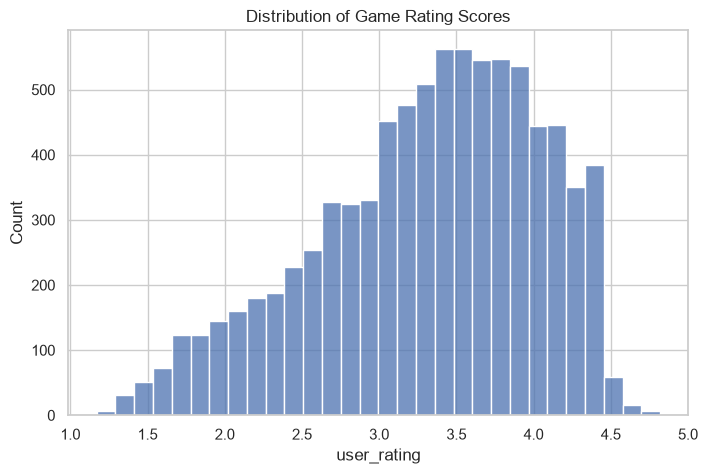

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df['user_rating'], bins=30)
plt.title('Distribution of Game Rating Scores')
plt.savefig('../images/rating_distribution.png')
plt.show()


In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 8441 entries, 0 to 14997
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               8441 non-null   str    
 1   release_date        8441 non-null   str    
 2   all_genres          8441 non-null   str    
 3   all_platforms       8441 non-null   str    
 4   user_rating         8441 non-null   float64
 5   metacritic          8441 non-null   float64
 6   avg_playtime_hours  8441 non-null   float64
 7   ratings_count       8441 non-null   float64
 8   main_genre          8441 non-null   str    
dtypes: float64(4), str(5)
memory usage: 659.5 KB


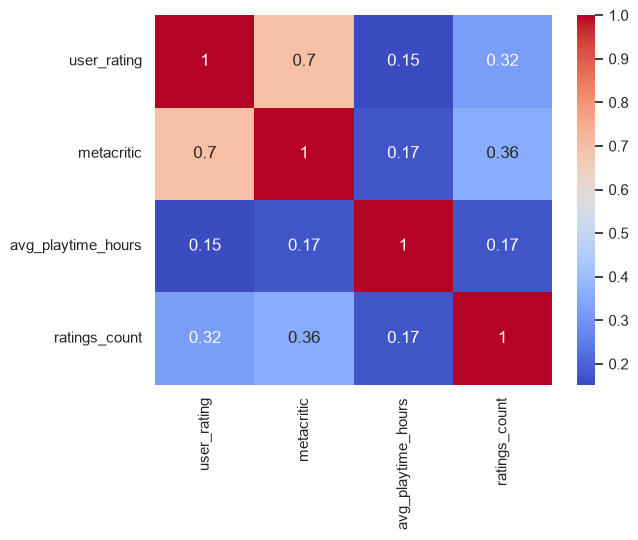

In [50]:
numeric_cols = ['user_rating','metacritic','avg_playtime_hours','ratings_count']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.savefig('../images/correlation_heatmap.png')
plt.show()


In [51]:
df.to_csv('../data/steam_games_clean.csv', index=False)